In [15]:
!nvidia-smi

Sat Jul 25 15:37:45 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   72C    P0             32W /   70W |    6063MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
%pip install -q tiktoken

!git clone -q https://github.com/zzkai098/reproduce-gpt2.git /content/reproduce-gpt2
%cd /content/reproduce-gpt2
!git pull

!curl -sL --create-dirs -o data/input.txt https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt
!ls -lh data/input.txt

/content/reproduce-gpt2
Already up to date.
-rw-r--r-- 1 root root 1.1M Jul 25 15:07 data/input.txt


In [3]:
import torch
import torch.nn as nn
from torch.nn import functional as F
import tiktoken
from gpt2.model import GPT, GPTConfig, DataLoaderLite

torch.manual_seed(1337)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device', device)
if device == 'cuda':
    print('GPU   :', torch.cuda.get_device_name(0))

device cuda
GPU   : Tesla T4


In [4]:
B, T = 2, 1024
train_loader = DataLoaderLite(B, T)

model = GPT(GPTConfig())
model.to(device)
#model = torch.compile(model)
# optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, betas=(0.9, 0.95), eps=1e-8,weight_decay=0.1) #refer the gpt3 paper
optimizer = model.configure_optimizers(
    weight_decay=0.1, # -> optim_groups
    learning_rate=3e-4,
    betas=(0.9, 0.95),
    device_type=device
)
# optimizer = torch.optim.AdamW(optim_groups, lr=learning_rate, betas=betas, eps=1e-8, fused=use_fused)

print('params:', sum(p.numel() for p in model.parameters()))


decayed tensors: 50, 124,318,464 params
non-decayed tensors: 98, 121,344 params
using fused AdamW: True
params: 124439808


In [8]:
import time

for i in range(50):
    t0 = time.time()
    optimizer.zero_grad()
    xb, yb = train_loader.next_batch()
    xb, yb = xb.to(device), yb.to(device)
    #with torch.autocast(device_type=device, dtype=torch.bfloat16):
    logits, loss = model(xb, yb)
    loss.backward()
    
    # gradient clipping
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) #no more than 1
    
    optimizer.step()
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 #ms
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1-t0)
    print(f"step {i} | loss: {loss.item():.4f} | norm: {norm:.4f} | dt: {dt:.2f} ms | tok/sec: {tokens_per_sec:.0f}")
        

OutOfMemoryError: CUDA out of memory. Tried to allocate 48.00 MiB. GPU 0 has a total capacity of 14.56 GiB of which 43.81 MiB is free. Process 941 has 10.67 GiB memory in use. Including non-PyTorch memory, this process has 3.85 GiB memory in use. Of the allocated memory 3.69 GiB is allocated by PyTorch, and 36.74 MiB is reserved by PyTorch but unallocated. If reserved but unallocated memory is large try setting PYTORCH_CUDA_ALLOC_CONF=expandable_segments:True to avoid fragmentation.  See documentation for Memory Management  (https://docs.pytorch.org/docs/stable/notes/cuda.html#optimizing-memory-usage-with-pytorch-cuda-alloc-conf)

In [14]:
""" torch.nn.utils.clip_grad_norm_?
Clip the gradient norm of an iterable of parameters.

The norm is computed over the norms of the individual gradients of all parameters,
as if the norms of the individual gradients were concatenated into a single vector.
Gradients are modified in-place. """

' torch.nn.utils.clip_grad_norm_?\nClip the gradient norm of an iterable of parameters.\n\nThe norm is computed over the norms of the individual gradients of all parameters,\nas if the norms of the individual gradients were concatenated into a single vector.\nGradients are modified in-place. '

In [9]:
# learning rate -> warmup + cosine decay
""" LR
   │        ___
   │      /     \___
   │    /            \___
   │  /                   \________  ← finally stop at min_lr
   │/
   └──┬────┬──────────────────┬──→ step
    warmup  ↑cosine decay       max_steps
1. warmup: lr = max_lr * (it+1) / warmup_steps
2. Cosine decay: coeff = 0.5 * (1.0 + cos(π × decay_ratio))
3. min_lr
"""
import math

max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 10
max_steps = 50

def get_lr(it):
    # warmup
    if it < warmup_steps:
        return max_lr * (it + 1) / warmup_steps
    
    # min_lr
    if it > max_steps:
        return min_lr
    
    # Cosine decay
    decay_ratio = (it - warmup_steps) / (max_steps - warmup_steps) # 0 -> 1
    assert 0 <= decay_ratio <= 1
    coeff = 0.5 * (1.0 + math.cos(math.pi * decay_ratio)) # 1 -> 0
    return min_lr + coeff * (max_lr - min_lr)



<>:4: SyntaxWarning: invalid escape sequence '\_'
<>:4: SyntaxWarning: invalid escape sequence '\_'
/tmp/ipykernel_1288/3606435651.py:4: SyntaxWarning: invalid escape sequence '\_'
  │      /     \___


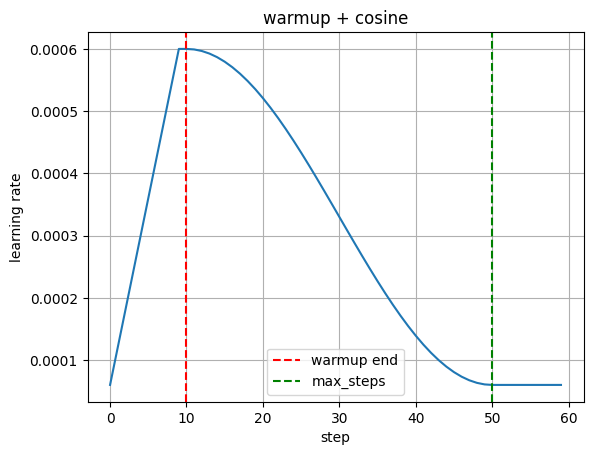

In [28]:
import matplotlib.pyplot as plt
lrs = [get_lr(it) for it in range(max_steps + 10)]
plt.plot(lrs)
plt.xlabel('step'); plt.ylabel('learning rate'); plt.title('warmup + cosine')
plt.axvline(warmup_steps, color='r', ls='--', label='warmup end')
plt.axvline(max_steps, color='g', ls='--', label='max_steps')
plt.legend(); plt.grid(True)

In [10]:
import time
max_lr = 6e-4
min_lr = max_lr * 0.1
warmup_steps = 10
max_steps = 50

for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    xb, yb = train_loader.next_batch()
    xb, yb = xb.to(device), yb.to(device)
    #with torch.autocast(device_type=device, dtype=torch.bfloat16):
    logits, loss = model(xb, yb)
    loss.backward()    
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # gradient clipping
    
    lr = get_lr(step)
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr                
    optimizer.step()
    
    torch.cuda.synchronize()
    t1 = time.time()
    dt = (t1 - t0)*1000 #ms
    tokens_per_sec = (train_loader.B * train_loader.T) / (t1-t0)
    print(f"step {step} | loss: {loss.item():.4f} | norm: {norm:.4f} | lr: {lr:.2e} | dt: {dt:.2f} ms | tok/sec: {tokens_per_sec:.0f}")


step 0 | loss: 10.9346 | norm: 31.6300 | lr: 6.00e-05 | dt: 1102.78 ms | tok/sec: 1857
step 1 | loss: 9.6135 | norm: 10.7918 | lr: 1.20e-04 | dt: 506.28 ms | tok/sec: 4045
step 2 | loss: 9.5202 | norm: 14.8262 | lr: 1.80e-04 | dt: 525.83 ms | tok/sec: 3895
step 3 | loss: 9.5616 | norm: 6.4991 | lr: 2.40e-04 | dt: 509.11 ms | tok/sec: 4023
step 4 | loss: 9.0861 | norm: 4.0284 | lr: 3.00e-04 | dt: 514.80 ms | tok/sec: 3978
step 5 | loss: 8.6891 | norm: 3.0230 | lr: 3.60e-04 | dt: 513.82 ms | tok/sec: 3986
step 6 | loss: 8.3697 | norm: 2.8134 | lr: 4.20e-04 | dt: 506.73 ms | tok/sec: 4042
step 7 | loss: 8.1627 | norm: 2.2517 | lr: 4.80e-04 | dt: 505.88 ms | tok/sec: 4048
step 8 | loss: 7.7371 | norm: 2.6005 | lr: 5.40e-04 | dt: 512.92 ms | tok/sec: 3993
step 9 | loss: 7.4071 | norm: 2.8837 | lr: 6.00e-04 | dt: 515.52 ms | tok/sec: 3973
step 10 | loss: 6.9979 | norm: 1.8524 | lr: 6.00e-04 | dt: 517.17 ms | tok/sec: 3960
step 11 | loss: 6.4716 | norm: 1.6148 | lr: 5.99e-04 | dt: 514.84 ms |

In [ ]:
# weight decay - regularization
# w = w - lr·wd·decay 

""" optimizer = torch.optim.AdamW(model.parameters(), 
                              lr=3e-4, 
                              betas=(0.9, 0.95), 
                              eps=1e-8,
                              weight_decay=0.1, # w = w - lr·wd·decay 
                              ) #refer the gpt3 paper """
# param_dict = {pn:p for pn, p in self.named_parameters() if p.requires_grad}                              
# decay_params = [p for p in param_dict.values() if p.dim() >= 2] # 2d matrix weight need decay
# nodecay_params = [p for p in param_dict.values() if p.dim() < 2] # 1d bias, layernorm do not need decay

In [ ]:
# batch_token = 0.5m, -> 0.5m/1024 -> B = 488.28125
# But this is too big for gpu, the hbm not enough 
# gradient accumulation
# let big batch decompose small micro-batch, then grad accum


In [ ]:
total_batch_size = 524288 # 2**19 = 0.5m
B, T = 16, 1024
assert total_batch_size % (B*T) == 0
grad_accum_steps = total_batch_size // (B * T) # 32
print(f"grad_accum_steps: {grad_accum_steps}")

for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    loss_accum = 0.0
    for micro_step in range(grad_accum_steps):
        xb, yb = train_loader.next_batch()
        xb, yb = xb.to(device), yb.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(xb, yb)
        loss = loss / grad_accum_steps
        loss_accum += loss.detach() # loss accum
        loss.backward() #grad accum
        
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # grad clip
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    optimizer.step()
    torch.cuda.synchronize()
    dt = (time.time() - t0) * 1000
    tok_per_sec = total_batch_size / (time.time() - t0)
    print(f"step {step} | loss {loss_accum:.4f} | norm {norm:.4f} | lr {lr:.2e} | dt {dt:.0f}ms | tok/s {tok_per_sec:.0f}")
        

In [13]:
total_batch_size = 8192 
B, T = 4, 256
assert total_batch_size % (B*T) == 0
grad_accum_steps = total_batch_size // (B * T) # 32
print(f"grad_accum_steps: {grad_accum_steps}")

for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    loss_accum = 0.0
    for micro_step in range(grad_accum_steps):
        xb, yb = train_loader.next_batch()
        xb, yb = xb.to(device), yb.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(xb, yb)
        loss = loss / grad_accum_steps
        loss_accum += loss.detach() # loss accum
        loss.backward() #grad accum
        
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # grad clip
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    optimizer.step()
    torch.cuda.synchronize()
    dt = (time.time() - t0) * 1000
    tok_per_sec = total_batch_size / (time.time() - t0)
    print(f"step {step} | loss {loss_accum:.4f} | norm {norm:.4f} | lr {lr:.2e} | dt {dt:.0f}ms | tok/s {tok_per_sec:.0f}")
        

grad_accum_steps: 8
step 0 | loss 6.5396 | norm 0.6213 | lr 6.00e-05 | dt 7705ms | tok/s 1063
step 1 | loss 6.4117 | norm 0.8144 | lr 1.20e-04 | dt 7953ms | tok/s 1030
step 2 | loss 6.4270 | norm 1.0458 | lr 1.80e-04 | dt 7793ms | tok/s 1051
step 3 | loss 6.3466 | norm 1.0930 | lr 2.40e-04 | dt 7325ms | tok/s 1118
step 4 | loss 6.3059 | norm 0.7185 | lr 3.00e-04 | dt 7015ms | tok/s 1168
step 5 | loss 6.2262 | norm 1.2433 | lr 3.60e-04 | dt 6840ms | tok/s 1198
step 6 | loss 6.2532 | norm 0.7975 | lr 4.20e-04 | dt 6784ms | tok/s 1208
step 7 | loss 6.3988 | norm 1.1825 | lr 4.80e-04 | dt 6759ms | tok/s 1212
step 8 | loss 6.3796 | norm 1.0366 | lr 5.40e-04 | dt 6796ms | tok/s 1205
step 9 | loss 6.2921 | norm 1.0474 | lr 6.00e-04 | dt 6863ms | tok/s 1194
step 10 | loss 6.4443 | norm 1.2775 | lr 6.00e-04 | dt 6974ms | tok/s 1175
step 11 | loss 6.3675 | norm 1.2722 | lr 5.99e-04 | dt 7094ms | tok/s 1155
step 12 | loss 6.2888 | norm 1.1768 | lr 5.97e-04 | dt 7224ms | tok/s 1134
step 13 | loss 

In [ ]:
# DDP - DistributedDataParallel
# data parallelism
# 每张 GPU 放一份完整的模型副本,各自处理不同的数据,反向后把梯度在所有 GPU 间「平均同步」,让所有副本保持一致。

""" gpu0: model + data0 -> grad0
gpu1: model + data1 -> grad1
gpu2: model + data2 -> grad2
gpu3: model + data3 -> grad3
gpu4: model + data4 -> grad4

(g0 + g1 ... + g8) / 8 -> grad """

""" DDP 不是一个进程用多张卡,而是启动 N 个独立的 Python 进程,每个进程绑一张
  GPU。torchrun 负责启动这 N 个进程,并给每个进程设好环境变量:

  ┌────────────┬────────────────────────────────┬─────────┐
  │  环境变量  │              含义              │ 例(8卡) │
  ├────────────┼────────────────────────────────┼─────────┤
  │ WORLD_SIZE │ 总进程数(总 GPU 数)            │ 8       │
  ├────────────┼────────────────────────────────┼─────────┤
  │ RANK       │ 这个进程的全局编号             │ 0~7     │
  ├────────────┼────────────────────────────────┼─────────┤
  │ LOCAL_RANK │ 这个进程在本机的编号(用哪张卡) │ 0~7     │
  └────────────┴────────────────────────────────┴─────────┘
 """

In [ ]:
from torch.distributed import init_process_group, destroy_process_group
from torch.nn.parallel import DistributedDataParallel as DDP
import torch.distributed as dist
import os

ddp = int(os.environ.get('RANK', -1)) != -1   
if ddp:
    init_process_group(backend='nccl')        
    
    ddp_rank       = int(os.environ['RANK'])
    ddp_local_rank = int(os.environ['LOCAL_RANK'])
    ddp_world_size = int(os.environ['WORLD_SIZE'])
    
    device = f'cuda:{ddp_local_rank}'
    torch.cuda.set_device(device)
    master_process = (ddp_rank == 0)           
else:
    ddp_rank, ddp_local_rank, ddp_world_size = 0, 0, 1
    master_process = True
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

In [ ]:
# Data sharding across DDP processes:
# Assume 4 processes, each reads one chunk of B*T tokens per batch.
# The token stream is cut into chunks:
#
#   tokens:
#[chunk0][chunk1][chunk2][chunk3][chunk4][chunk5][chunk6][chunk7][chunk8]...
#
#   process 0: start=0, stride=4  ->  reads chunk0, chunk4, chunk8, ...
#   process 1: start=1, stride=4  ->  reads chunk1, chunk5, chunk9, ...
#   process 2: start=2, stride=4  ->  reads chunk2, chunk6, ...
#   process 3: start=3, stride=4  ->  reads chunk3, chunk7, ...
#
# Together the 4 processes cover every chunk exactly once — no overlap, no gaps.
# Each process sees a different 1/N of the data (N = num_processes).

class DataLoaderLite:
    def __init__(self, B, T, process_rank, num_processes):
        self.B = B
        self.T = T
        self.process_rank = process_rank
        self.num_processes = num_processes
        
        with open('data/input.txt', 'r') as f:
            text = f.read()
        enc = tiktoken.get_encoding('gpt2')
        self.tokens = torch.tensor(enc.encode(text))
        
        # each process starts at its own offset (staggered by rank)
        self.current_position = self.B * self.T * self.process_rank 
        
    def next_batch(self):
        B, T = self.B, self.T
        buf = self.tokens[self.current_position : self.current_position+B*T + 1]
        
        x = buf[:-1].view(B, T)
        y = buf[1:].view(B, T)
        # advance by the full stride so processes never read each other's chunks
        self.current_position += B * T * self.num_processes
        if self.current_position + (B*T*self.num_processes + 1) > len(self.tokens):
            self.current_position = self.B * self.T * self.process_rank
        return x, y

In [ ]:
total_batch_size = 524288 # 2**19 = 0.5m
B, T = 16, 1024
assert total_batch_size % (B * T * ddp_world_size) == 0
grad_accum_steps = total_batch_size // (B * T * ddp_world_size) # 524288 // (16 * 1024 * 8) = 4, each gpu now have 4 accum steps
if master_process:
    print(f"total desired batch size: {total_batch_size}")
    print(f"grad_accum_steps: {grad_accum_steps}")
    
train_loader = DataLoaderLite(B=B, T=T, process_rank=ddp_rank, num_processes=ddp_world_size)
torch.set_float32_matmul_precision('high')

#creat model 
model = GPT(GPTConfig())
model.to(device)
model = torch.compile(model)
if ddp:
    model = DDP(model, device_ids=[ddp_local_rank])
raw_model = model.module if ddp else model


for step in range(max_steps):
    t0 = time.time()
    optimizer.zero_grad()
    
    loss_accum = 0.0
    for micro_step in range(grad_accum_steps):
        xb, yb = train_loader.next_batch()
        xb, yb = xb.to(device), yb.to(device)
        with torch.autocast(device_type=device, dtype=torch.bfloat16):
            logits, loss = model(xb, yb)
        loss = loss / grad_accum_steps
        loss_accum += loss.detach() # loss accum
        if ddp:
            model.require_backward_grad_sync = (micro_step == grad_accum_steps-1)
        loss.backward() #grad accum
    if ddp:
        dist.all_reduce(loss_accum, op=dist.ReduceOp.AVG)
    norm = torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0) # grad clip
    lr = get_lr(step)
    for pg in optimizer.param_groups:
        pg['lr'] = lr
    optimizer.step()
    torch.cuda.synchronize()
    dt = (time.time() - t0) * 1000
    tok_per_sec = total_batch_size / (time.time() - t0)
    if master_process:
        print(f"step {step} | loss {loss_accum:.4f} | norm {norm:.4f} | lr {lr:.2e} | dt {dt:.0f}ms | tok/s {tok_per_sec:.0f}")
        
    if ddp:
        destroy_process_group()
        